# Test notebook for the processing part of SFG-App2

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from sfg_app2.processing.data_file import DataFile

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
fp1 = "C:/Users/silan/Desktop/Research/programming/SFG-app2/SFG-App2/tests/data/new batteries/2026_06_12/simon/csv files/LiFSI in DME_SCE_1V_ssp_3.3um_60s_1457_20260612.csv"
fp2 = "C:/Users/silan/Desktop/Research/programming/SFG-app2/SFG-App2/tests/data/new batteries/2026_06_12/simon/csv files/polystyrene_ssp_3.3um_10s_1003_20260612.csv"
fp3 = "C:/Users/silan/Desktop/Research/programming/SFG-app2/SFG-App2/tests/data/new batteries/2026_06_12/simon/csv files/LiFSI in DME_SCE_OCP_ssp_3.3um_60s_1027_20260612_bg.csv"
fp4 = "C:/Users/silan/Desktop/Research/programming/SFG-app2/SFG-App2/tests/data/new batteries/2026_06_12/simon/csv files/zqz_ssp_3.3um_10s_1006_20260612.csv"
fp5 = "C:/Users/silan/Desktop/Research/programming/SFG-app2/SFG-App2/tests/data/new batteries/2026_06_12/simon/csv files/zqz_ssp_3.3um_10s_0959_20260612_bg.csv"

In [4]:
f1 = DataFile(fp1, filename_fields=['sample', 'concentration', 'potential', 'polarization', 'center wavelength', 'acquisition time', 'timestamp', 'date'])
f2 = DataFile(fp2, filename_fields=['sample', 'polarization', 'center wavelength', 'acquisition time', 'timestamp', 'date'])
f3 = DataFile(fp3, filename_fields=['sample', 'concentration', 'potential', 'polarization', 'center wavelength', 'acquisition time', 'timestamp', 'date'])
f4 = DataFile(fp4, filename_fields=['sample', 'polarization', 'center wavelength', 'acquisition time', 'timestamp', 'date'])
f5 = DataFile(fp5, filename_fields=['sample', 'polarization', 'center wavelength', 'acquisition time', 'timestamp', 'date'])

files = [f1, f2, f3, f4, f5]

for f in files:
    print(f)

DataFile(LiFSI in DME_SCE_1V_ssp_3.3um_60s_1457_20260612.csv, n_frames=2, metadata={'source_filename': 'LiFSI in DME_SCE_1V_ssp_3.3um_60s_1457_20260612.csv', 'sample': 'LiFSI in DME', 'concentration': 'SCE', 'potential': '1V', 'polarization': 'ssp', 'center wavelength': '3.3um', 'acquisition time': '60s', 'timestamp': '1457', 'date': '20260612'})
DataFile(polystyrene_ssp_3.3um_10s_1003_20260612.csv, n_frames=3, metadata={'source_filename': 'polystyrene_ssp_3.3um_10s_1003_20260612.csv', 'sample': 'polystyrene', 'polarization': 'ssp', 'center wavelength': '3.3um', 'acquisition time': '10s', 'timestamp': '1003', 'date': '20260612'})
DataFile(LiFSI in DME_SCE_OCP_ssp_3.3um_60s_1027_20260612_bg.csv, n_frames=2, metadata={'source_filename': 'LiFSI in DME_SCE_OCP_ssp_3.3um_60s_1027_20260612_bg.csv', 'sample': 'LiFSI in DME', 'concentration': 'SCE', 'potential': 'OCP', 'polarization': 'ssp', 'center wavelength': '3.3um', 'acquisition time': '60s', 'timestamp': '1027', 'date': '20260612', 'extr

In [5]:
import matplotlib.pyplot as plt

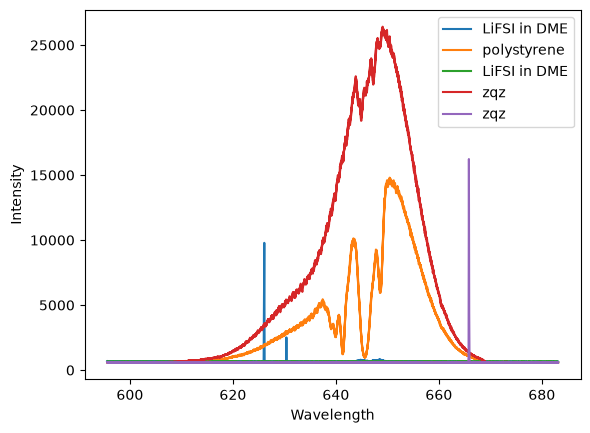

In [6]:
for f in files:
    plt.plot(
        f.raw_data["Wavelength"],
        f.raw_data["Intensity"],
        label=f.metadata["sample"]
        )
    plt.xlabel("Wavelength")
    plt.ylabel("Intensity")

plt.legend()

(600.0, 850.0)

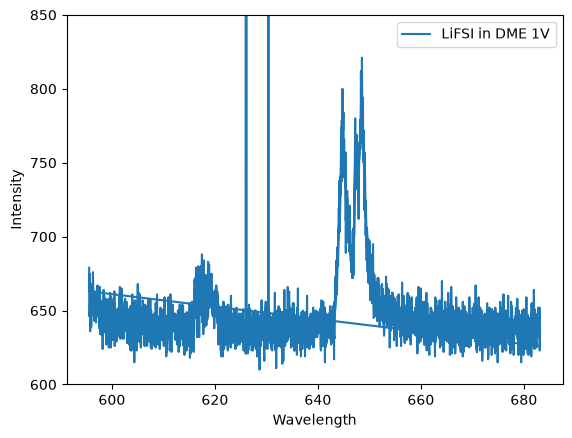

In [7]:
plt.plot(
        f1.raw_data["Wavelength"],
        f1.raw_data["Intensity"],
        label=f"{f1.metadata["sample"]} {f1.metadata["potential"]}"
        )
plt.xlabel("Wavelength")
plt.ylabel("Intensity")
plt.legend()
plt.ylim(600, 850)

(600.0, 850.0)

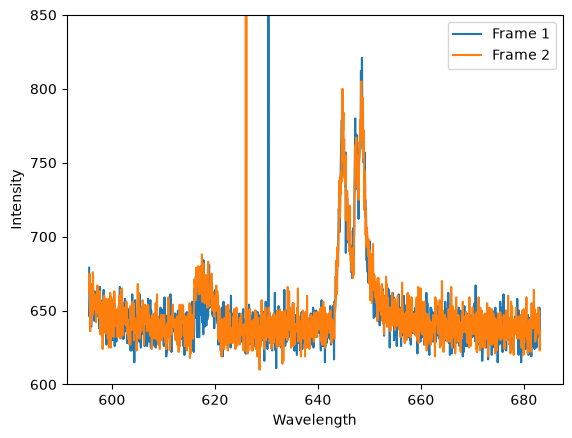

In [8]:
for frame in range(f1.n_frames):
    frame += 1
    plt.plot(
        f1.frame(frame)["Wavelength"],
        f1.frame(frame)["Intensity"],
        label=f"Frame {frame}"
        )
plt.xlabel("Wavelength")
plt.ylabel("Intensity")
plt.legend()
plt.ylim(600, 850)

(600.0, 850.0)

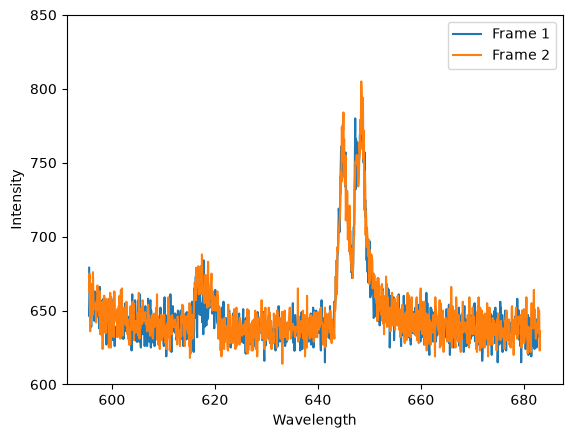

In [15]:
f1_cleaned = f1.remove_cosmic_rays()
for frame in range(f1_cleaned.n_frames):
    frame += 1
    plt.plot(
        f1_cleaned.frame(frame)["Wavelength"],
        f1_cleaned.frame(frame)["Intensity"],
        label=f"Frame {frame}"
        )
plt.xlabel("Wavelength")
plt.ylabel("Intensity")
plt.legend()
plt.ylim(600, 850)

(600.0, 850.0)

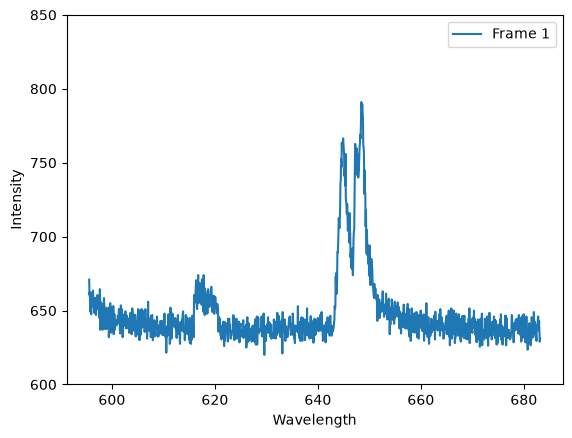

In [18]:
f1_cleaned_averaged = f1.remove_cosmic_rays().average_spectrum()
for frame in range(f1_cleaned_averaged.n_frames):
    frame += 1
    plt.plot(
        f1_cleaned_averaged.frame(frame)["Wavelength"],
        f1_cleaned_averaged.frame(frame)["Intensity"],
        label=f"Frame {frame}"
        )
plt.xlabel("Wavelength")
plt.ylabel("Intensity")
plt.legend()
plt.ylim(600, 850)